In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Preparação dos dados

In [2]:
#Carregar os dados
dataset = pd.read_csv(r'C:\Users\mateu\OneDrive\Documentos\SPTECH\TCC\backend\tabela_final\part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv')

# Prepara a coluna de datas para o split temporal ANTES de apagá-la do dataset principal
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
split_date = pd.to_datetime('2018-07-01', utc=True)
date_col = pd.to_datetime(dataset['order_delivered_carrier_date'], utc=True)


# Remover colunas conforme solicitado (clima e vazamento de dados)
colunas_remover = [
    # Vazamento de dados / Pós-compra (ocorrem após aprovação ou derivam do tempo de entrega)
    'order_delivered_customer_date', 
    'order_delivered_carrier_date',
    'review_score', 
    # 'delivered_on_time', # Vamos manter esta no df principal apenas para análises descritivas, não passaremos ela para 'X'.
    'approval_time_hours', 
    'handling_time_hours', 
    'shipping_delay_hours',
    
    # Variáveis climáticas (Vendedor)
    'seller_total_rainfall_period_mm',
    'seller_max_rain_intensity_mm_h',
    'seller_max_wind_gust_period_ms',
    'seller_interval_code',
    'seller_rain_class_code',
    'seller_wind_class_code',
    'seller_accumulated_rainfall_3_days_mm',
    'seller_is_heavy_rain',
    'seller_is_strong_wind',
    
    # Variáveis climáticas (Cliente)
    'customer_total_rainfall_period_mm',
    'customer_max_rain_intensity_mm_h',
    'customer_max_wind_gust_period_ms',
    'customer_interval_code',
    'customer_rain_class_code',
    'customer_wind_class_code',
    'customer_accumulated_rainfall_3_days_mm',
    'customer_is_heavy_rain',
    'customer_is_strong_wind',

    'seller_meso_metropolitana_de_sao_paulo',
    'seller_meso_araraquara',
    'seller_meso_piracicaba',
    'seller_meso_ribeirao_preto',
    'seller_meso_sao_jose_do_rio_preto',
    'seller_meso_campinas',
    'seller_meso_vale_do_paraiba_paulista',
    'seller_meso_macro_metropolitana_paulista',
    'seller_meso_bauru',
    'seller_meso_presidente_prudente',
    'seller_meso_marilia',
    'seller_meso_assis',
    'seller_meso_aracatuba',
    'seller_meso_litoral_sul_paulista',
    'seller_meso_itapetininga',
    'customer_meso_metropolitana_de_sao_paulo',
    'customer_meso_piracicaba',
    'customer_meso_campinas',
    'customer_meso_vale_do_paraiba_paulista',
    'customer_meso_ribeirao_preto',
    'customer_meso_sao_jose_do_rio_preto',
    'customer_meso_macro_metropolitana_paulista',
    'customer_meso_bauru','customer_meso_araraquara',
    'customer_meso_presidente_prudente',
    'customer_meso_marilia',
    'customer_meso_assis',
    'customer_meso_aracatuba',
    'customer_meso_itapetininga',
    'customer_meso_litoral_sul_paulista'
]

df = dataset.drop(columns=colunas_remover)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33820 entries, 0 to 33819
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   holiday_at_shipping       33820 non-null  int64  
 1   delivery_time_days        33820 non-null  float64
 2   purchase_hour             33820 non-null  int64  
 3   purchase_day_of_week      33820 non-null  int64  
 4   is_weekend                33820 non-null  int64  
 5   price                     33820 non-null  float64
 6   freight_value             33820 non-null  float64
 7   product_weight_g          33820 non-null  int64  
 8   volume_cm3                33820 non-null  float64
 9   distance_km               33820 non-null  float64
 10  same_city                 33820 non-null  int64  
 11  delivered_on_time         33820 non-null  int64  
 12  seller_geolocation_lat    33820 non-null  float64
 13  seller_geolocation_lng    33820 non-null  float64
 14  customer_geolocat

In [4]:
# ============================================================
# SEÇÃO 1 — Definição das features e da variável alvo
# ============================================================

# Features selecionadas para o modelo.
# OBS: delivery_time_days ficou fora porque pode causar vazamento de dados:
# se o objetivo é prever atraso antes da entrega acontecer, não podemos usar o tempo real de entrega.
features = [
    'holiday_at_shipping',
    'purchase_hour',
    'purchase_day_of_week',
    'is_weekend',
    'price',
    'freight_value',
    'product_weight_g',
    'volume_cm3',
    'distance_km',
    'same_city',
    'seller_geolocation_lat',
    'seller_geolocation_lng',
    'customer_geolocation_lat',
    'customer_geolocation_lng',
    'month'
]

target = 'delivered_on_time'

# Validação para garantir que todas as colunas existem no DataFrame
missing_cols = [col for col in features + [target] if col not in df.columns]
if missing_cols:
    raise ValueError(f'As seguintes colunas não foram encontradas em df: {missing_cols}')

# Separar features (X) e target (y)
X = df[features].copy()
y = df[target].copy()

print('Quantidade de features usadas:', len(features))
print('Features usadas no modelo:')
print(X.columns.tolist())
print('\nTarget:', target)


Quantidade de features usadas: 15
Features usadas no modelo:
['holiday_at_shipping', 'purchase_hour', 'purchase_day_of_week', 'is_weekend', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km', 'same_city', 'seller_geolocation_lat', 'seller_geolocation_lng', 'customer_geolocation_lat', 'customer_geolocation_lng', 'month']

Target: delivered_on_time


### Divisão de treino e teste

In [5]:
# ============================================================
# SEÇÃO 2 — Split temporal treino/teste
# ============================================================

# Mantém exatamente a lógica temporal do arquivo:
# Treino: pedidos antes de 2018-07-01
# Teste : pedidos a partir de 2018-07-01
train_mask = date_col.loc[X.index] < split_date
test_mask = date_col.loc[X.index] >= split_date

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print('Shape X_train:', X_train.shape)
print('Shape X_test :', X_test.shape)

print('\nDistribuição da classe no treino:')
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print('\nDistribuição da classe no teste:')
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))


Treino: 28706 amostras | Teste: 5114 amostras
Shape X_train: (28706, 15)
Shape X_test : (5114, 15)

Distribuição da classe no treino:
delivered_on_time
1    27281
0     1425
Name: count, dtype: int64
delivered_on_time
1    95.04
0     4.96
Name: proportion, dtype: float64

Distribuição da classe no teste:
delivered_on_time
1    4501
0     613
Name: count, dtype: int64
delivered_on_time
1    88.01
0    11.99
Name: proportion, dtype: float64


In [6]:
# Análise descritiva do split
n_total = len(X)
n_train = int(train_mask.sum())
n_test = int(test_mask.sum())

# Contagem de atrasos (classe 0) em cada particao
n_train_atraso = int(y[train_mask].eq(0).sum())
n_test_atraso = int(y[test_mask].eq(0).sum())

# Calcular porcentagens de atrasos em cada particao
train_atraso_pct = f"{n_train_atraso / n_train:.2%}" if n_train else "0.00%"
test_atraso_pct = f"{n_test_atraso / n_test:.2%}" if n_test else "0.00%"

print(f"Total de registros: {n_total}\n")
print(f"Treino (até Jun/2018): {n_train} ({n_train/n_total:.2%})")
print(f" - Atrasos no Treino: {n_train_atraso} ({train_atraso_pct} do treino)\n")
print(f"Teste (Jul/2018 em diante): {n_test} ({n_test/n_total:.2%})")
print(f" - Atrasos no Teste: {n_test_atraso} ({test_atraso_pct} do teste)\n")

Total de registros: 33820

Treino (até Jun/2018): 28706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)



In [7]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [8]:
novo = X_test.iloc[[0]]
print(classifier.predict(novo))

[1]


In [9]:
y_pred = classifier.predict(X_test)

# Matriz de Confusão

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))


[[  34  579]
 [ 114 4387]]
0.8644896362925303
0.8834071687474829
0.9746722950455454


Propriedades do Classificador

In [11]:
print(classifier.predict_proba(novo))
print(classifier.classes_)
print(classifier.max_features_)
print(classifier.feature_importances_)
print(classifier.n_features_in_)

[[0. 1.]]
[0 1]
15
[0.         0.09520554 0.06133471 0.00876166 0.1393332  0.10032059
 0.11149481 0.11203204 0.18216236 0.00701862 0.03155684 0.03723759
 0.04745769 0.04093854 0.02514581]
15


Visualizar dados de treinamento

 



c:\Users\mateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


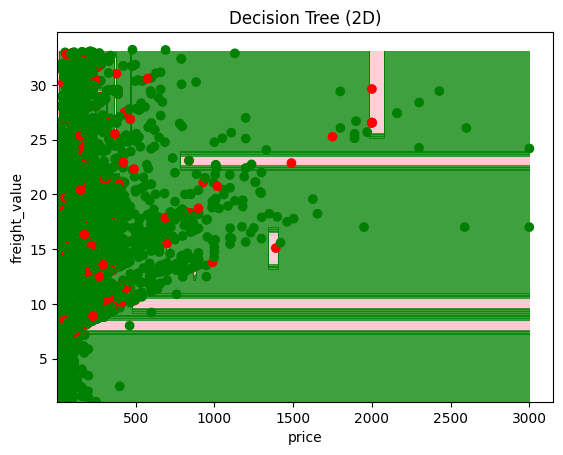

In [12]:
X_2d = dataset[["price", "freight_value"]]
y = dataset["delivered_on_time"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

X_set = X_train.values
y_set = y_train.values

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min(), stop=X_set[:, 0].max(), step=1),
    np.arange(start=X_set[:, 1].min(), stop=X_set[:, 1].max(), step=1)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('pink', 'green'))
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'green')))
plt.xlabel("price")
plt.ylabel("freight_value")
plt.title("Decision Tree (2D)")
plt.show()

Visualizar dados de teste

c:\Users\mateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\mateu\AppData\Local\Temp\ipykernel_4332\1824099838.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


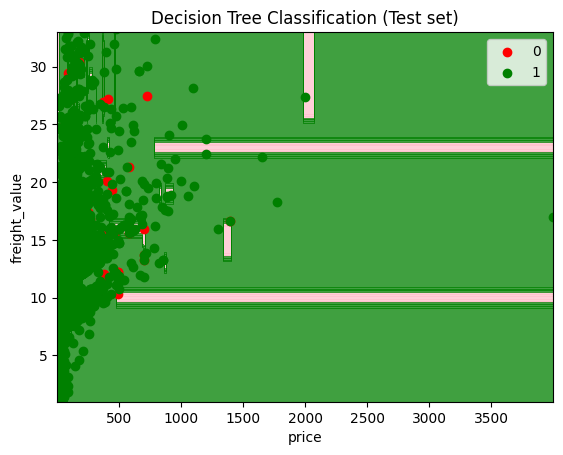

In [13]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

X_2d = dataset[["price", "freight_value"]]
y = dataset["delivered_on_time"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

X_set = X_test.values
y_set = y_test.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min(), stop=X_set[:, 0].max(), step=1),
    np.arange(start=X_set[:, 1].min(), stop=X_set[:, 1].max(), step=1)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('pink', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Decision Tree Classification (Test set)')
plt.xlabel('price')
plt.ylabel('freight_value')
plt.legend()
plt.show()

## Visualizar Matriz de Confusão e Árvore de Decisão

<Figure size 600x500 with 0 Axes>

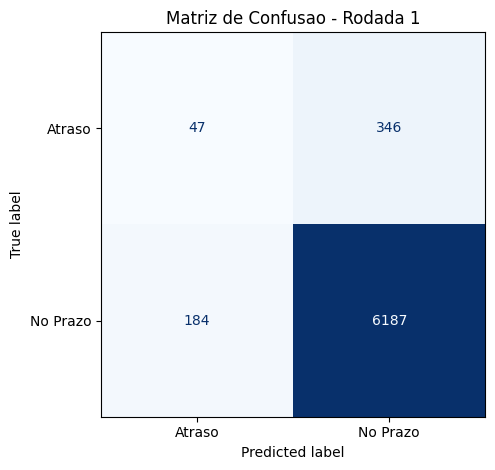

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Predicoes no conjunto de teste para a matriz de confusao
y_pred_tree = classifier.predict(X_test)
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=["Atraso", "No Prazo"]).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de Confusao - Rodada 1")
plt.tight_layout()
plt.show()

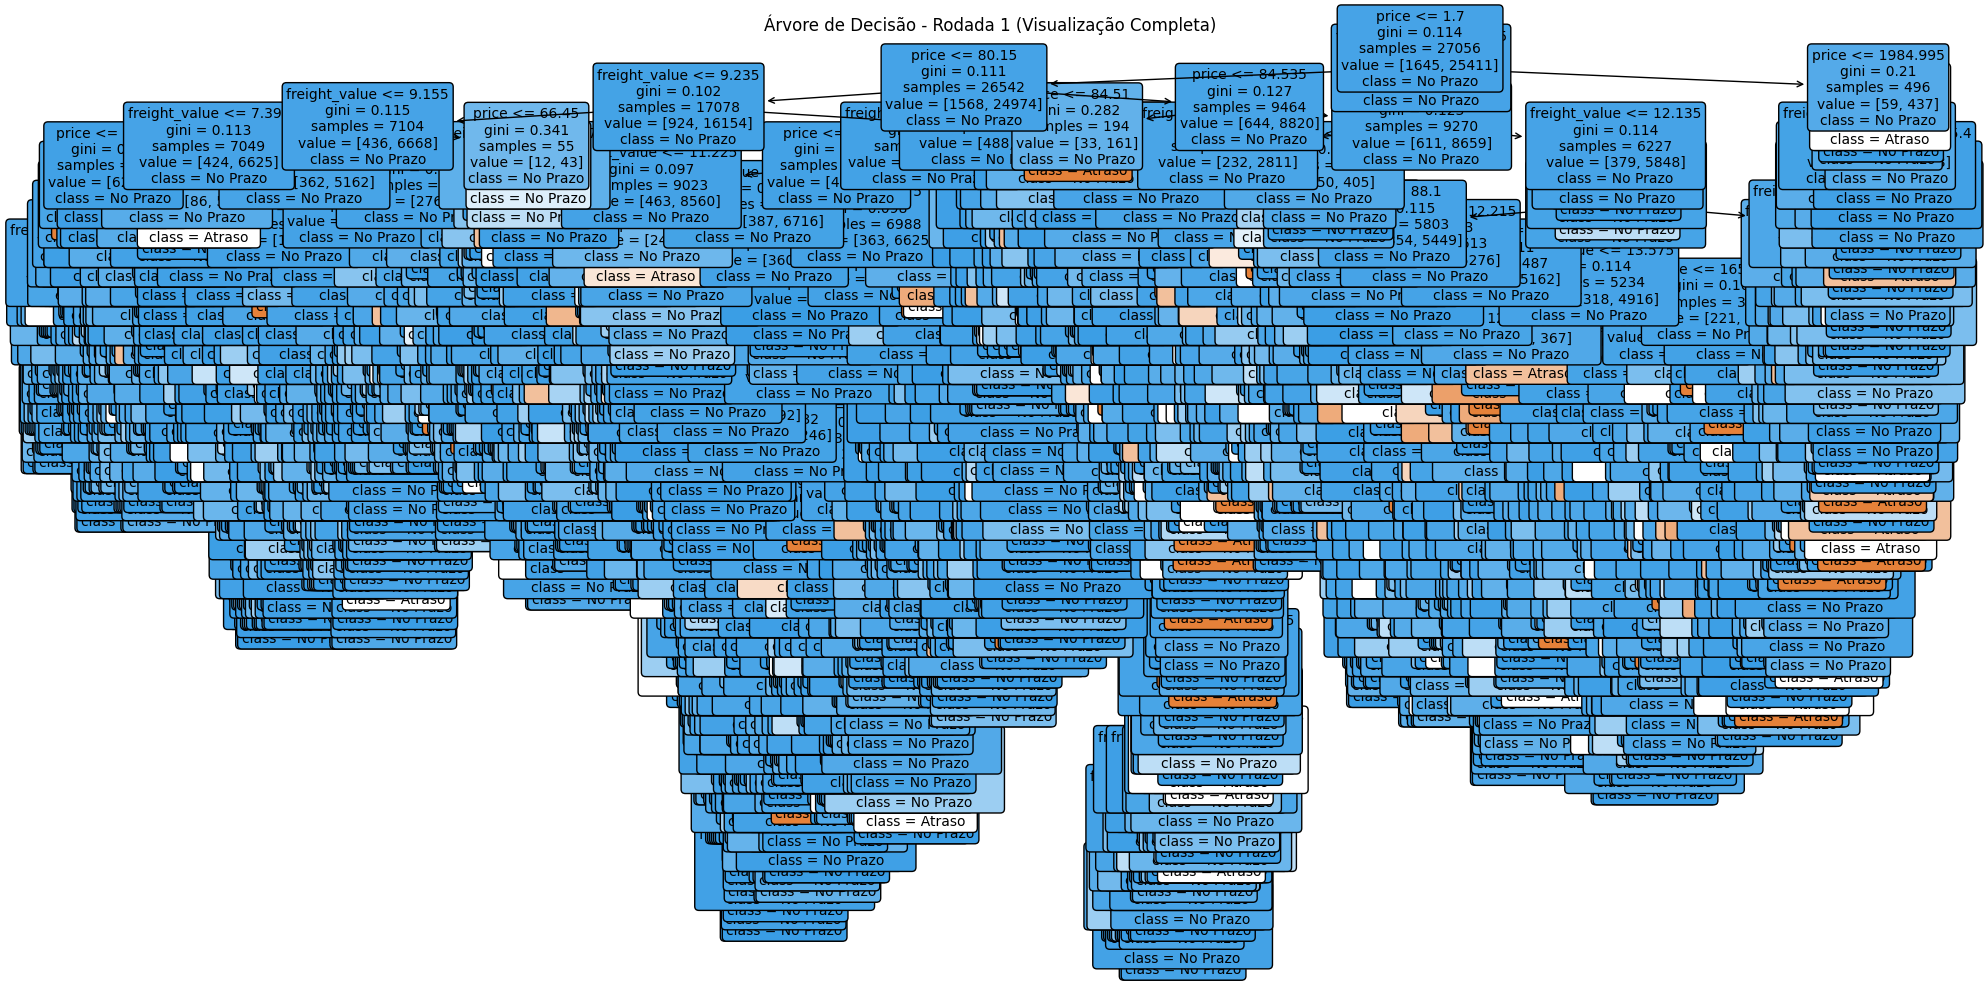

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    classifier, 
    feature_names=["price", "freight_value"], 
    class_names=["Atraso", "No Prazo"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árvore de Decisão - Rodada 1 (Visualização Completa)")
plt.tight_layout()
plt.show()

## Modelo Melhorado — Versão Corrigida Final

Esta seção mantém o **split temporal** do notebook e corrige o principal problema encontrado: o modelo anterior estava treinando apenas com `price` e `freight_value`. Agora, a árvore recebe todas as features relevantes criadas para o problema.

Principais ajustes:

- uso das 15 features corretas;
- remoção de `delivery_time_days` para evitar vazamento de dados;
- split temporal preservado;
- validação cruzada temporal com `TimeSeriesSplit`;
- `GridSearchCV` otimizado por `f1_macro`;
- árvore com poda e controle de complexidade;
- avaliação completa de treino, teste, matriz de confusão, threshold e importância das variáveis.


In [16]:
# ============================================================
# SEÇÃO 3 — Imports e preparação robusta do modelo final
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# ------------------------------------------------------------
# 3.1 — Definição explícita das features
# ------------------------------------------------------------

features = [
    'holiday_at_shipping',
    'purchase_hour',
    'purchase_day_of_week',
    'is_weekend',
    'price',
    'freight_value',
    'product_weight_g',
    'volume_cm3',
    'distance_km',
    'same_city',
    'seller_geolocation_lat',
    'seller_geolocation_lng',
    'customer_geolocation_lat',
    'customer_geolocation_lng',
    'month'
]

target = 'delivered_on_time'

# delivery_time_days NÃO entra nas features, pois pode representar vazamento de dados.
missing_cols = [col for col in features + [target] if col not in df.columns]
if missing_cols:
    raise ValueError(f'Colunas ausentes no DataFrame: {missing_cols}')

X = df[features].copy()
y = df[target].copy()

# ------------------------------------------------------------
# 3.2 — Split temporal preservado
# ------------------------------------------------------------

train_mask = date_col.loc[X.index] < split_date
test_mask = date_col.loc[X.index] >= split_date

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

if y_train.nunique() < 2:
    raise ValueError('A base de treino precisa conter pelo menos duas classes.')

print('=' * 90)
print('FEATURES E SPLIT TEMPORAL')
print('=' * 90)
print('Features usadas:', X_train.columns.tolist())
print('Shape treino:', X_train.shape)
print('Shape teste :', X_test.shape)

print('\nDistribuição da classe no treino:')
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

print('\nDistribuição da classe no teste:')
print(y_test.value_counts())
print((y_test.value_counts(normalize=True) * 100).round(2))

# ------------------------------------------------------------
# 3.3 — Preprocessamento
# ------------------------------------------------------------

numeric_features = features

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
    ],
    remainder='drop'
)

# ------------------------------------------------------------
# 3.4 — Pipeline da árvore de decisão
# ------------------------------------------------------------

pipeline = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced'
        )),
    ]
)

# ------------------------------------------------------------
# 3.5 — GridSearch com validação temporal
# ------------------------------------------------------------

param_grid = {
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [5, 8, 10, 15, 20],
    'model__min_samples_split': [10, 20, 50],
    'model__min_samples_leaf': [5, 10, 20],
    'model__max_leaf_nodes': [20, 50, 100, 200, None],
    'model__ccp_alpha': [0.0001, 0.001, 0.005, 0.01],
}

cv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
    verbose=2,
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print('\n' + '=' * 90)
print('MELHOR CONFIGURAÇÃO ENCONTRADA')
print('=' * 90)
print(grid.best_params_)
print(f'Melhor F1 Macro no CV temporal: {grid.best_score_:.4f}')

print('\nFeatures que realmente chegaram na árvore:')
print(best_model.named_steps['preprocess'].get_feature_names_out())


FEATURES E SPLIT TEMPORAL
Features usadas: ['holiday_at_shipping', 'purchase_hour', 'purchase_day_of_week', 'is_weekend', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km', 'same_city', 'seller_geolocation_lat', 'seller_geolocation_lng', 'customer_geolocation_lat', 'customer_geolocation_lng', 'month']
Shape treino: (28706, 15)
Shape teste : (5114, 15)

Distribuição da classe no treino:
delivered_on_time
1    27281
0     1425
Name: count, dtype: int64
delivered_on_time
1    95.04
0     4.96
Name: proportion, dtype: float64

Distribuição da classe no teste:
delivered_on_time
1    4501
0     613
Name: count, dtype: int64
delivered_on_time
1    88.01
0    11.99
Name: proportion, dtype: float64
Fitting 5 folds for each of 2700 candidates, totalling 13500 fits

MELHOR CONFIGURAÇÃO ENCONTRADA
{'model__ccp_alpha': 0.005, 'model__criterion': 'gini', 'model__max_depth': 8, 'model__max_leaf_nodes': 20, 'model__min_samples_leaf': 5, 'model__min_samples_split': 10}
Melhor F1

In [17]:
# ============================================================
# SEÇÃO 4 — Diagnóstico de overfitting: treino x teste
# ============================================================

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

metricas_treino_teste = pd.DataFrame({
    'Base': ['Treino', 'Teste'],
    'Accuracy': [
        accuracy_score(y_train, train_pred),
        accuracy_score(y_test, test_pred),
    ],
    'Precision Macro': [
        precision_score(y_train, train_pred, average='macro', zero_division=0),
        precision_score(y_test, test_pred, average='macro', zero_division=0),
    ],
    'Recall Macro': [
        recall_score(y_train, train_pred, average='macro', zero_division=0),
        recall_score(y_test, test_pred, average='macro', zero_division=0),
    ],
    'F1 Macro': [
        f1_score(y_train, train_pred, average='macro', zero_division=0),
        f1_score(y_test, test_pred, average='macro', zero_division=0),
    ],
    'F1 Weighted': [
        f1_score(y_train, train_pred, average='weighted', zero_division=0),
        f1_score(y_test, test_pred, average='weighted', zero_division=0),
    ],
})

print('=' * 90)
print('MÉTRICAS TREINO X TESTE')
print('=' * 90)
display(metricas_treino_teste)

f1_gap = metricas_treino_teste.loc[0, 'F1 Macro'] - metricas_treino_teste.loc[1, 'F1 Macro']
print(f'Gap de F1 Macro treino - teste: {f1_gap:.4f}')


MÉTRICAS TREINO X TESTE


,Base,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0,Treino,0.736884,0.523835,0.596528,0.493590,0.809749
1,Teste,0.880133,0.440066,0.500000,0.468123,0.824020


Gap de F1 Macro treino - teste: 0.0255


CLASSIFICATION REPORT — TESTE TEMPORAL
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       613
           1       0.88      1.00      0.94      4501

    accuracy                           0.88      5114
   macro avg       0.44      0.50      0.47      5114
weighted avg       0.77      0.88      0.82      5114

Matriz de confusão — limiar padrão 0.50:


,Previsto atraso/0,Previsto no prazo/1
Real atraso/0,0,613
Real no prazo/1,0,4501


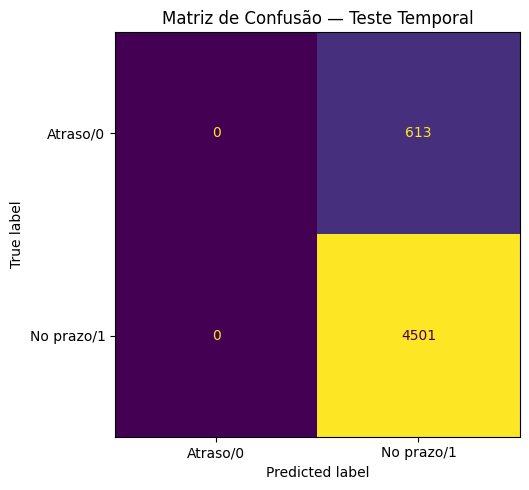


Métricas de probabilidade:
ROC-AUC: 0.5000
PR-AUC : 0.8801


In [18]:
# ============================================================
# SEÇÃO 5 — Avaliação no conjunto de teste temporal
# ============================================================

y_test_pred_default = best_model.predict(X_test)

print('=' * 90)
print('CLASSIFICATION REPORT — TESTE TEMPORAL')
print('=' * 90)
print(classification_report(y_test, y_test_pred_default, zero_division=0))

cm_default = confusion_matrix(y_test, y_test_pred_default)
matriz_confusao_default = pd.DataFrame(
    cm_default,
    index=['Real atraso/0', 'Real no prazo/1'],
    columns=['Previsto atraso/0', 'Previsto no prazo/1']
)

print('Matriz de confusão — limiar padrão 0.50:')
display(matriz_confusao_default)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_default,
    display_labels=['Atraso/0', 'No prazo/1']
).plot(ax=ax, colorbar=False)
ax.set_title('Matriz de Confusão — Teste Temporal')
plt.tight_layout()
plt.show()

if hasattr(best_model, 'predict_proba'):
    y_test_proba_default = best_model.predict_proba(X_test)[:, 1]
    print('\nMétricas de probabilidade:')
    print(f'ROC-AUC: {roc_auc_score(y_test, y_test_proba_default):.4f}')
    print(f'PR-AUC : {average_precision_score(y_test, y_test_proba_default):.4f}')


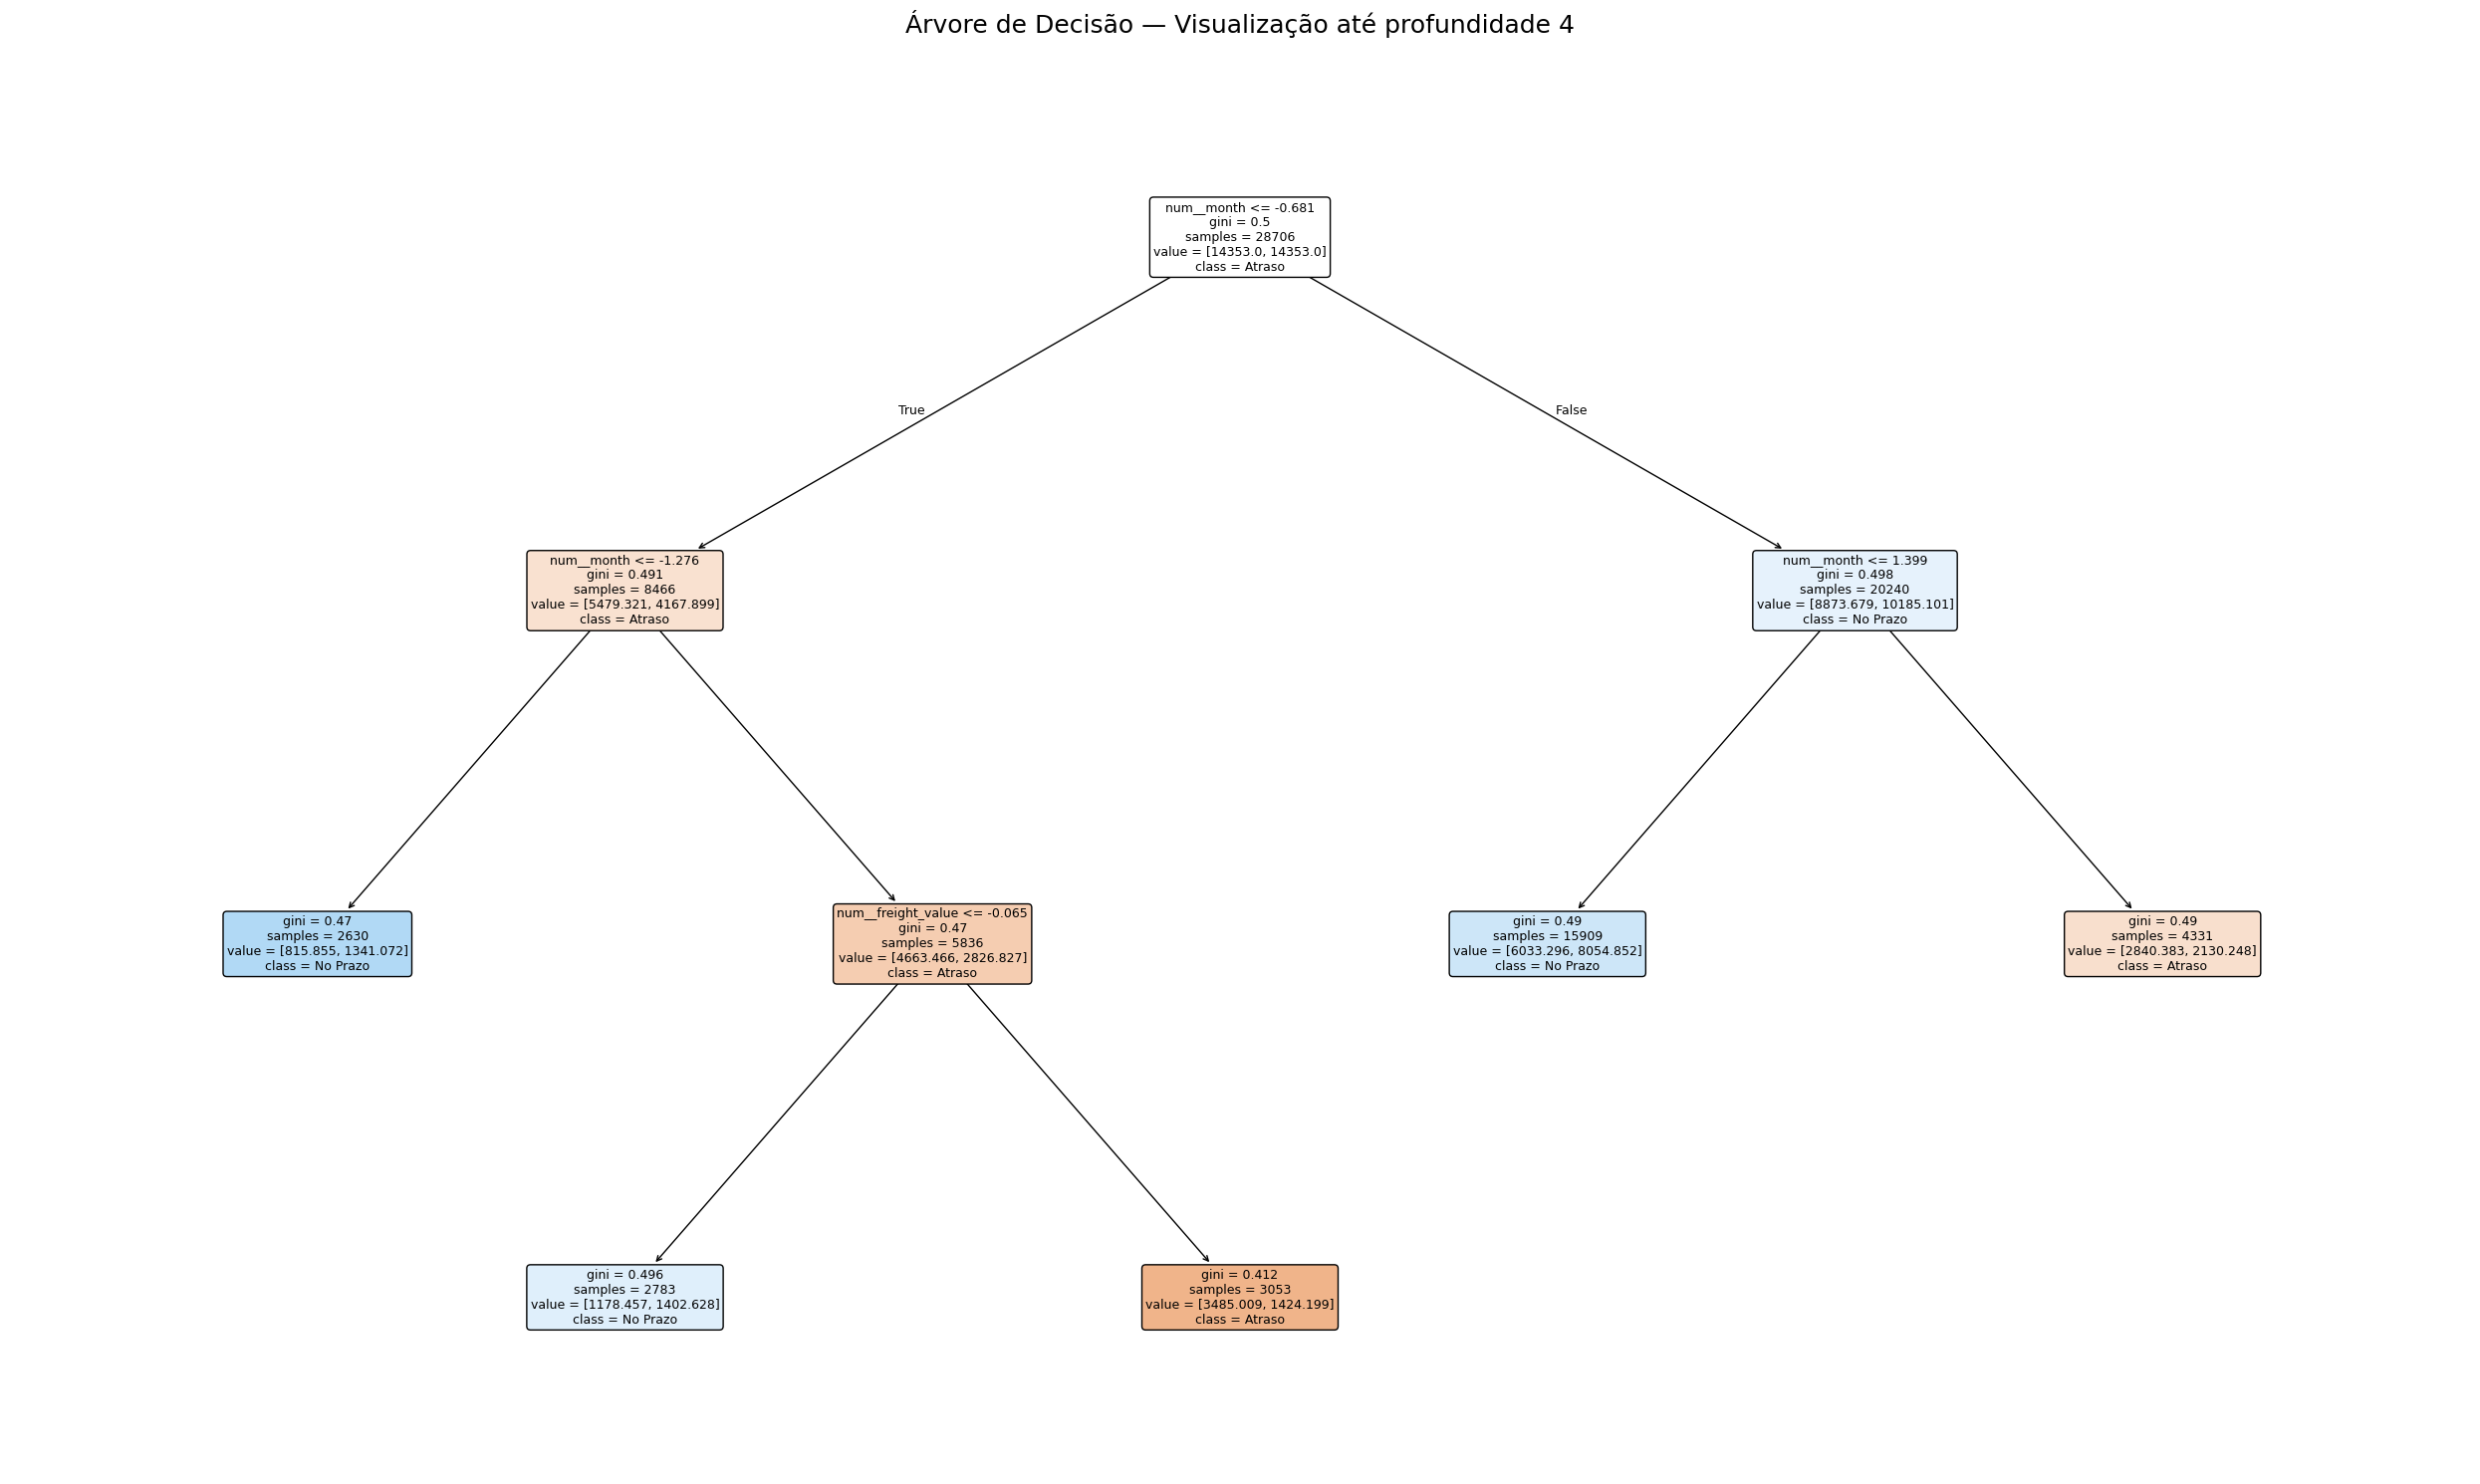

Profundidade da árvore completa: 3
Quantidade de folhas: 5
Quantidade total de nós: 9
Número de features usadas: 15


In [19]:
# ============================================================
# SEÇÃO 6 — Visualização da árvore e complexidade
# ============================================================

from sklearn.tree import plot_tree

arvore = best_model.named_steps['model']
feature_names = best_model.named_steps['preprocess'].get_feature_names_out().tolist()

plt.figure(figsize=(25, 15))
plot_tree(
    arvore,
    feature_names=feature_names,
    class_names=['Atraso', 'No Prazo'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4
)
plt.title('Árvore de Decisão — Visualização até profundidade 4', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

print('Profundidade da árvore completa:', arvore.get_depth())
print('Quantidade de folhas:', arvore.get_n_leaves())
print('Quantidade total de nós:', arvore.tree_.node_count)
print('Número de features usadas:', arvore.n_features_in_)


IMPORTÂNCIA DAS VARIÁVEIS


,Variavel,Importancia
14,num__month,0.690727
5,num__freight_value,0.309273
1,num__purchase_hour,0.000000
2,num__purchase_day_of_week,0.000000
3,num__is_weekend,0.000000
4,num__price,0.000000
0,num__holiday_at_shipping,0.000000
6,num__product_weight_g,0.000000
7,num__volume_cm3,0.000000
9,num__same_city,0.000000


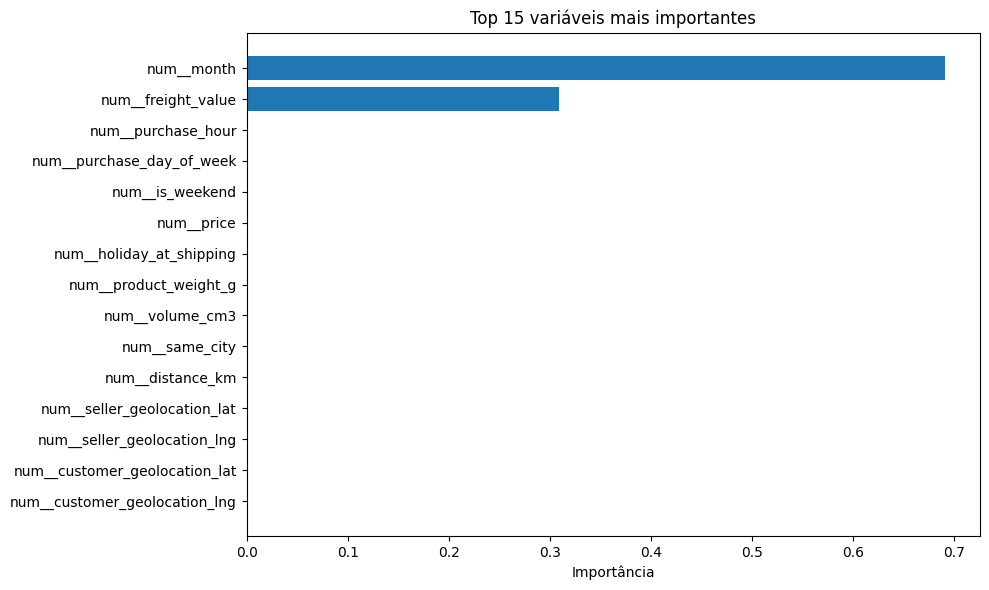

In [20]:
# ============================================================
# SEÇÃO 7 — Importância das variáveis
# ============================================================

feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Variavel': feature_names,
    'Importancia': importances,
}).sort_values('Importancia', ascending=False)

print('=' * 90)
print('IMPORTÂNCIA DAS VARIÁVEIS')
print('=' * 90)
display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Variavel'].head(15)[::-1], importance_df['Importancia'].head(15)[::-1])
plt.xlabel('Importância')
plt.title('Top 15 variáveis mais importantes')
plt.tight_layout()
plt.show()


In [21]:
# ============================================================
# SEÇÃO 8 — Ajuste de threshold usando validação temporal interna
# ============================================================

# Para não usar o teste final na escolha do limiar, separamos os últimos 20% do treino
# como validação temporal. Assim, continuamos respeitando a lógica temporal.
val_size = int(len(X_train) * 0.20)

X_train_inner = X_train.iloc[:-val_size].copy()
y_train_inner = y_train.iloc[:-val_size].copy()
X_val = X_train.iloc[-val_size:].copy()
y_val = y_train.iloc[-val_size:].copy()

print('Treino interno:', X_train_inner.shape)
print('Validação temporal interna:', X_val.shape)

# Retreina o melhor pipeline encontrado apenas no treino interno
best_params_clean = {key.replace('model__', ''): value for key, value in grid.best_params_.items()}

model_threshold = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced',
            **best_params_clean
        )),
    ]
)

model_threshold.fit(X_train_inner, y_train_inner)

val_proba_class1 = model_threshold.predict_proba(X_val)[:, 1]

threshold_results = []
for threshold in np.arange(0.05, 0.96, 0.01):
    # Como predict_proba[:, 1] é a probabilidade de classe 1 (no prazo),
    # valores menores indicam maior chance de atraso.
    val_pred_threshold = (val_proba_class1 >= threshold).astype(int)
    threshold_results.append({
        'Threshold': threshold,
        'Precision Macro': precision_score(y_val, val_pred_threshold, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_val, val_pred_threshold, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_val, val_pred_threshold, average='macro', zero_division=0),
        'F1 Weighted': f1_score(y_val, val_pred_threshold, average='weighted', zero_division=0),
        'Recall Classe 0': recall_score(y_val, val_pred_threshold, pos_label=0, zero_division=0),
        'Precision Classe 0': precision_score(y_val, val_pred_threshold, pos_label=0, zero_division=0),
        'F1 Classe 0': f1_score(y_val, val_pred_threshold, pos_label=0, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold = threshold_df.sort_values('F1 Macro', ascending=False).iloc[0]['Threshold']

print('=' * 90)
print('MELHORES THRESHOLDS NA VALIDAÇÃO TEMPORAL INTERNA')
print('=' * 90)
display(threshold_df.sort_values('F1 Macro', ascending=False).head(10))
print(f'Melhor threshold selecionado: {best_threshold:.2f}')

# Retreina o modelo final no treino temporal completo usando os melhores hiperparâmetros
best_model_v2 = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('model', DecisionTreeClassifier(
            random_state=42,
            class_weight='balanced',
            **best_params_clean
        )),
    ]
)
best_model_v2.fit(X_train, y_train)

# Predição no teste final com threshold ajustado
y_test_proba = best_model_v2.predict_proba(X_test)[:, 1]
y_test_pred_tuned = (y_test_proba >= best_threshold).astype(int)
y_test_pred_default = best_model_v2.predict(X_test)

print('\n' + '=' * 90)
print('CLASSIFICATION REPORT — TESTE COM THRESHOLD AJUSTADO')
print('=' * 90)
print(classification_report(y_test, y_test_pred_tuned, zero_division=0))


Treino interno: (22965, 15)
Validação temporal interna: (5741, 15)
MELHORES THRESHOLDS NA VALIDAÇÃO TEMPORAL INTERNA


,Threshold,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Recall Classe 0,Precision Classe 0,F1 Classe 0
26,0.31,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
25,0.30,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
35,0.40,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
34,0.39,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
33,0.38,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
48,0.53,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
47,0.52,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
46,0.51,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
45,0.50,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329
44,0.49,0.536938,0.600622,0.541293,0.889874,0.319672,0.106996,0.160329


Melhor threshold selecionado: 0.31

CLASSIFICATION REPORT — TESTE COM THRESHOLD AJUSTADO
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       613
           1       0.88      1.00      0.94      4501

    accuracy                           0.88      5114
   macro avg       0.44      0.50      0.47      5114
weighted avg       0.77      0.88      0.82      5114



COMPARAÇÃO ENTRE LIMIARES


,Cenario,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Recall Classe 0,Precision Classe 0,F1 Classe 0
0,Limiar padrão 0.50,0.8801,0.4401,0.5,0.4681,0.824,0.0,0.0,0.0
1,Limiar ajustado 0.31,0.8801,0.4401,0.5,0.4681,0.824,0.0,0.0,0.0



Matriz de confusão — limiar ajustado:


,Previsto atraso/0,Previsto no prazo/1
Real atraso/0,0,613
Real no prazo/1,0,4501


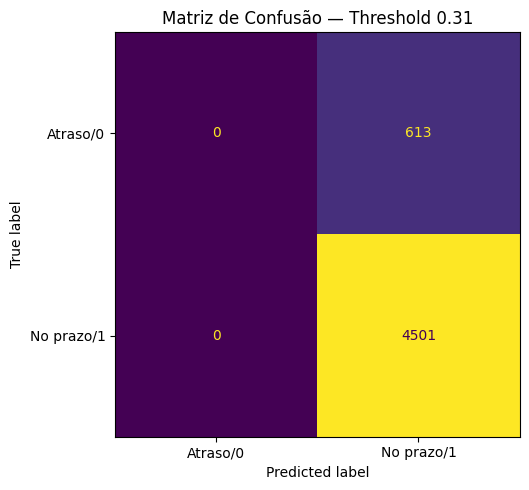

In [22]:
# ============================================================
# SEÇÃO 9 — Comparação: limiar padrão x limiar ajustado
# ============================================================

comparacao_threshold = pd.DataFrame([
    {
        'Cenario': 'Limiar padrão 0.50',
        'Accuracy': accuracy_score(y_test, y_test_pred_default),
        'Precision Macro': precision_score(y_test, y_test_pred_default, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_test, y_test_pred_default, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_test, y_test_pred_default, average='macro', zero_division=0),
        'F1 Weighted': f1_score(y_test, y_test_pred_default, average='weighted', zero_division=0),
        'Recall Classe 0': recall_score(y_test, y_test_pred_default, pos_label=0, zero_division=0),
        'Precision Classe 0': precision_score(y_test, y_test_pred_default, pos_label=0, zero_division=0),
        'F1 Classe 0': f1_score(y_test, y_test_pred_default, pos_label=0, zero_division=0),
    },
    {
        'Cenario': f'Limiar ajustado {best_threshold:.2f}',
        'Accuracy': accuracy_score(y_test, y_test_pred_tuned),
        'Precision Macro': precision_score(y_test, y_test_pred_tuned, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_test, y_test_pred_tuned, average='macro', zero_division=0),
        'F1 Macro': f1_score(y_test, y_test_pred_tuned, average='macro', zero_division=0),
        'F1 Weighted': f1_score(y_test, y_test_pred_tuned, average='weighted', zero_division=0),
        'Recall Classe 0': recall_score(y_test, y_test_pred_tuned, pos_label=0, zero_division=0),
        'Precision Classe 0': precision_score(y_test, y_test_pred_tuned, pos_label=0, zero_division=0),
        'F1 Classe 0': f1_score(y_test, y_test_pred_tuned, pos_label=0, zero_division=0),
    }
])

print('=' * 90)
print('COMPARAÇÃO ENTRE LIMIARES')
print('=' * 90)
display(comparacao_threshold.round(4))

cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
matriz_confusao_tuned = pd.DataFrame(
    cm_tuned,
    index=['Real atraso/0', 'Real no prazo/1'],
    columns=['Previsto atraso/0', 'Previsto no prazo/1']
)

print('\nMatriz de confusão — limiar ajustado:')
display(matriz_confusao_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=['Atraso/0', 'No prazo/1']
).plot(ax=ax, colorbar=False)
ax.set_title(f'Matriz de Confusão — Threshold {best_threshold:.2f}')
plt.tight_layout()
plt.show()


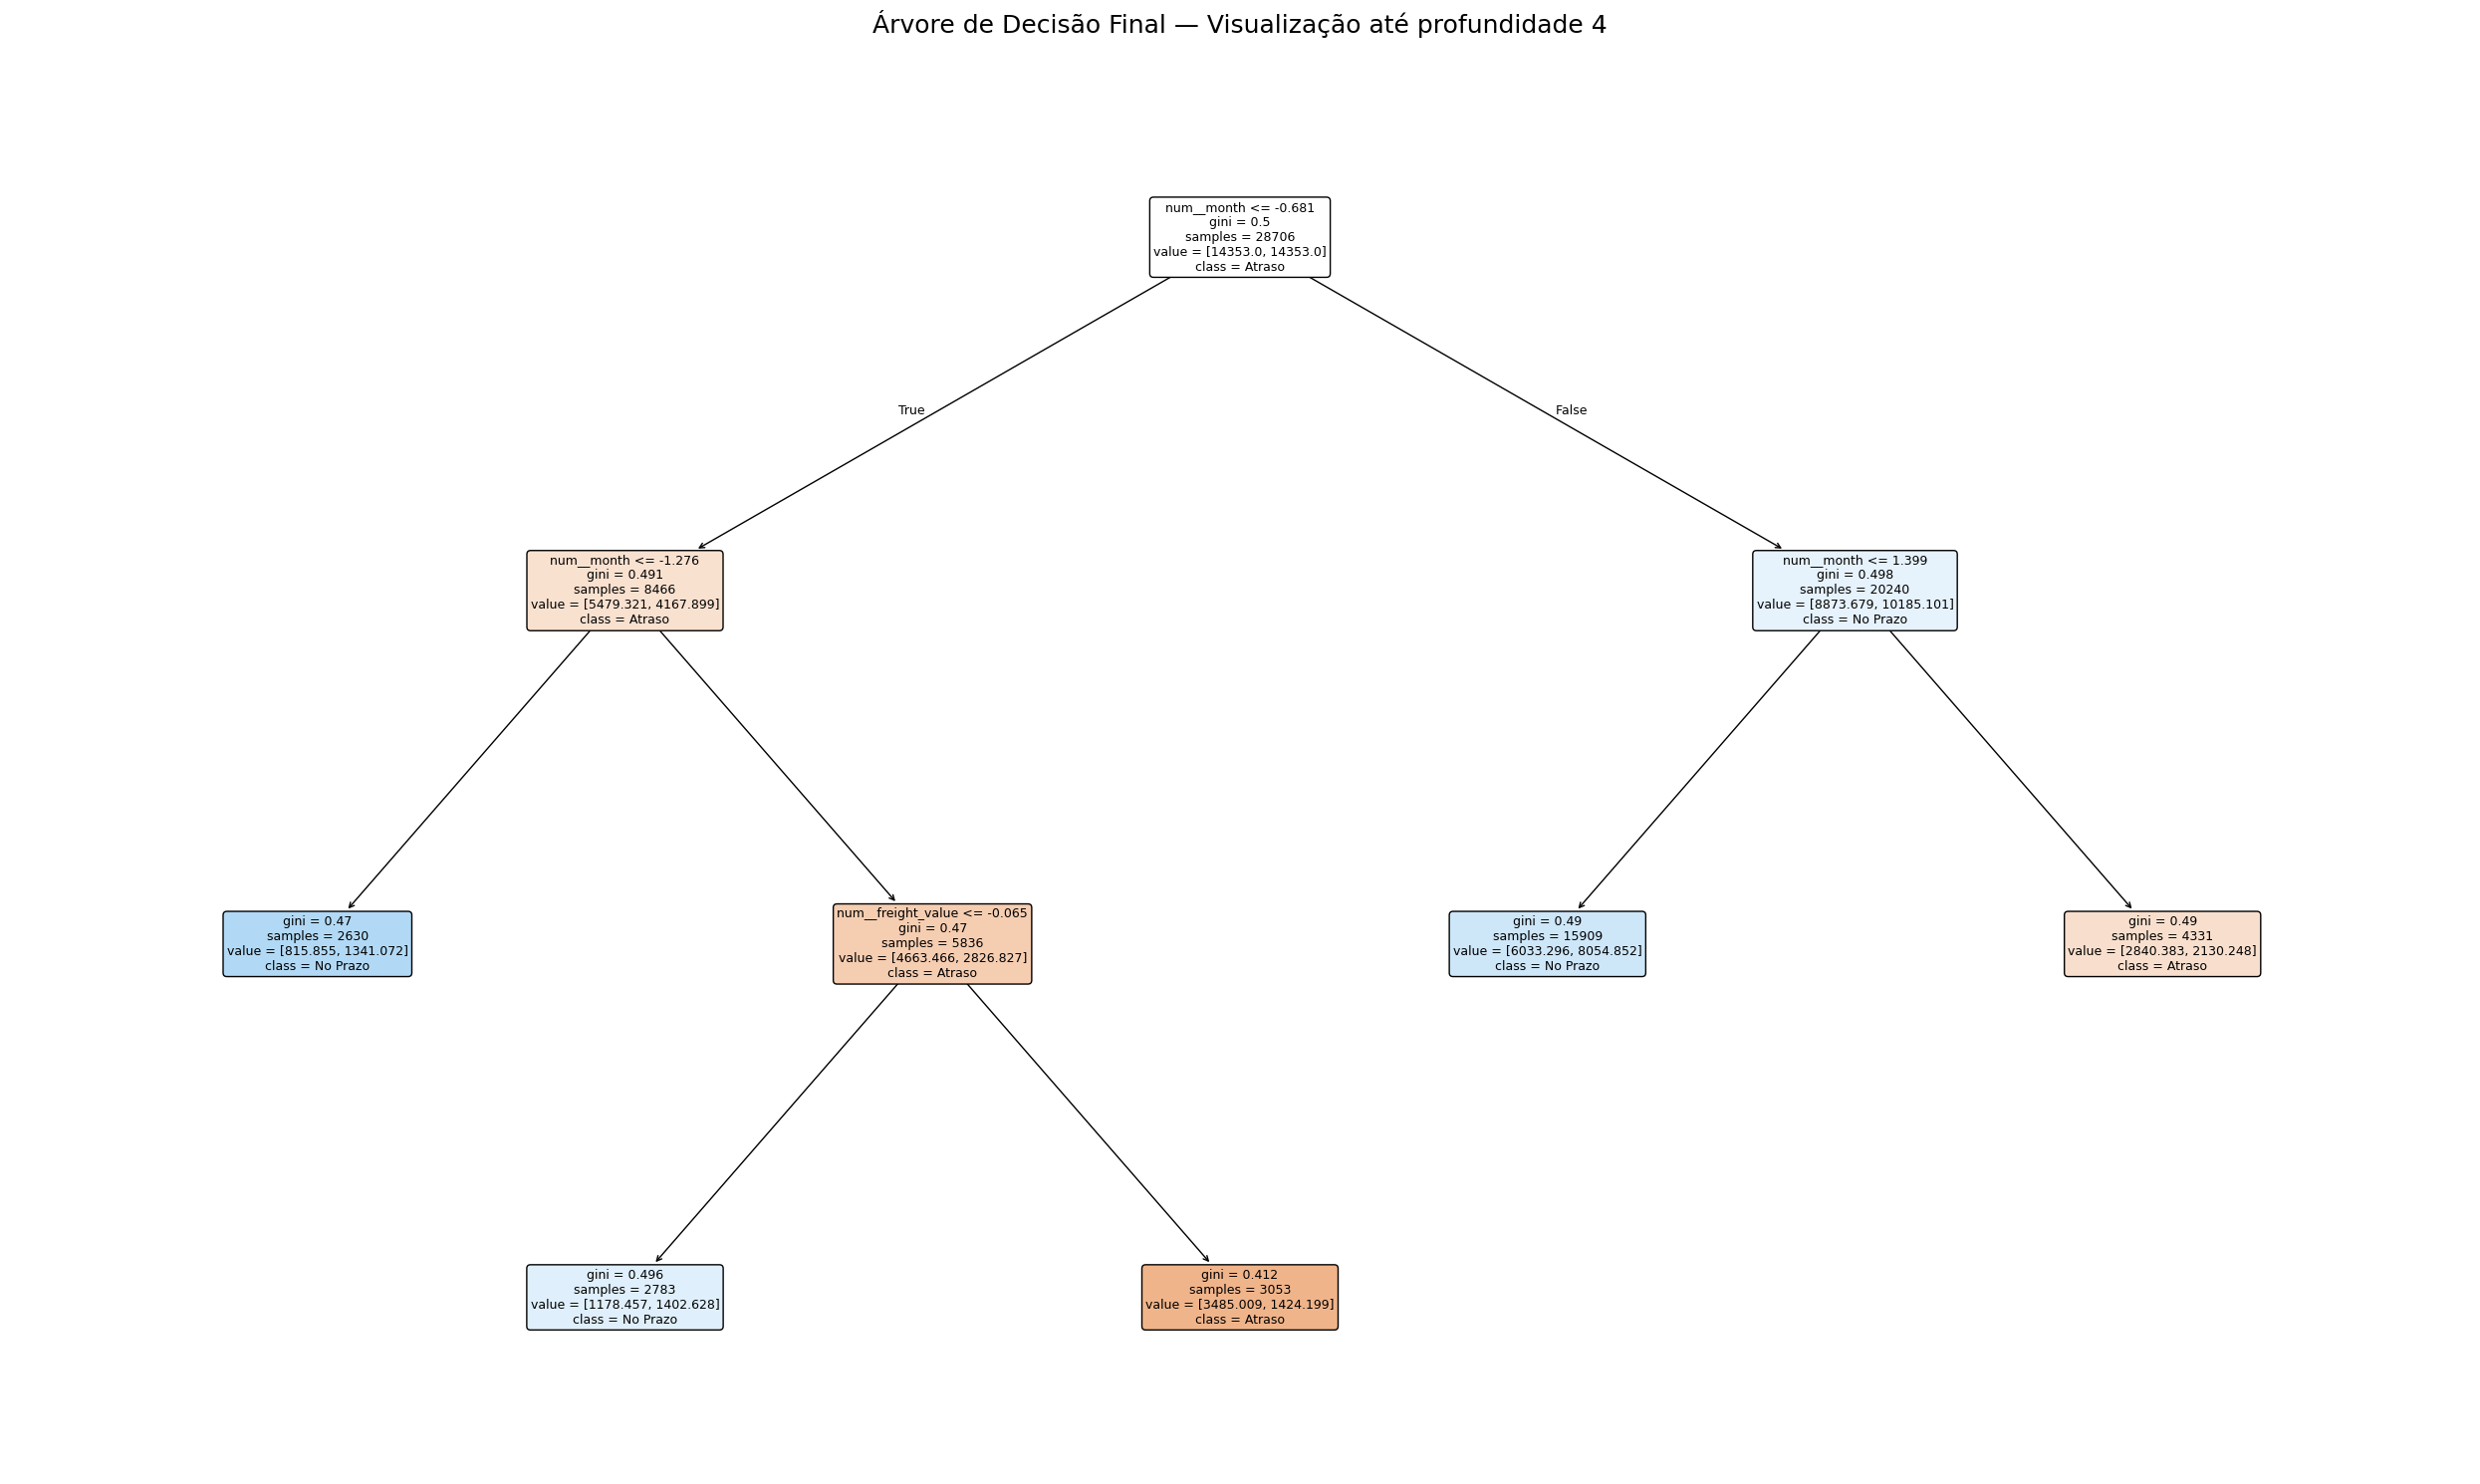

Profundidade da árvore completa: 3
Quantidade de folhas: 5
Quantidade total de nós: 9
Número de features usadas: 15

Hiperparâmetros finais:
{'ccp_alpha': 0.005, 'criterion': 'gini', 'max_depth': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 5, 'min_samples_split': 10}


In [23]:
# ============================================================
# SEÇÃO 10 — Árvore final após threshold e melhores hiperparâmetros
# ============================================================

from sklearn.tree import plot_tree

tree_model_v2 = best_model_v2.named_steps['model']
feature_names_v2 = best_model_v2.named_steps['preprocess'].get_feature_names_out().tolist()

plt.figure(figsize=(25, 15))
plot_tree(
    tree_model_v2,
    feature_names=feature_names_v2,
    class_names=['Atraso', 'No Prazo'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=4
)
plt.title('Árvore de Decisão Final — Visualização até profundidade 4', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

print('Profundidade da árvore completa:', tree_model_v2.get_depth())
print('Quantidade de folhas:', tree_model_v2.get_n_leaves())
print('Quantidade total de nós:', tree_model_v2.tree_.node_count)
print('Número de features usadas:', tree_model_v2.n_features_in_)
print('\nHiperparâmetros finais:')
print(best_params_clean)


In [24]:
# ============================================================
# SEÇÃO 11 — Métricas separadas para relatório
# ============================================================

print('=' * 90)
print('MÉTRICAS SEPARADAS — RELATÓRIO')
print('=' * 90)
print('LEGENDA:')
print('- Classe 0: pedidos que NÃO foram entregues no prazo / atraso')
print('- Classe 1: pedidos entregues no prazo')
print('- Macro: média simples entre as classes')
print('- Weighted: média ponderada pela quantidade de exemplos em cada classe')

# Limiar padrão
acc_default = accuracy_score(y_test, y_test_pred_default)
prec_default_macro = precision_score(y_test, y_test_pred_default, average='macro', zero_division=0)
rec_default_macro = recall_score(y_test, y_test_pred_default, average='macro', zero_division=0)
f1_default_macro = f1_score(y_test, y_test_pred_default, average='macro', zero_division=0)
prec_default_weighted = precision_score(y_test, y_test_pred_default, average='weighted', zero_division=0)
rec_default_weighted = recall_score(y_test, y_test_pred_default, average='weighted', zero_division=0)
f1_default_weighted = f1_score(y_test, y_test_pred_default, average='weighted', zero_division=0)
prec_default_c0 = precision_score(y_test, y_test_pred_default, pos_label=0, zero_division=0)
rec_default_c0 = recall_score(y_test, y_test_pred_default, pos_label=0, zero_division=0)
f1_default_c0 = f1_score(y_test, y_test_pred_default, pos_label=0, zero_division=0)
prec_default_c1 = precision_score(y_test, y_test_pred_default, pos_label=1, zero_division=0)
rec_default_c1 = recall_score(y_test, y_test_pred_default, pos_label=1, zero_division=0)
f1_default_c1 = f1_score(y_test, y_test_pred_default, pos_label=1, zero_division=0)

# Limiar ajustado
acc_tuned = accuracy_score(y_test, y_test_pred_tuned)
prec_tuned_macro = precision_score(y_test, y_test_pred_tuned, average='macro', zero_division=0)
rec_tuned_macro = recall_score(y_test, y_test_pred_tuned, average='macro', zero_division=0)
f1_tuned_macro = f1_score(y_test, y_test_pred_tuned, average='macro', zero_division=0)
prec_tuned_weighted = precision_score(y_test, y_test_pred_tuned, average='weighted', zero_division=0)
rec_tuned_weighted = recall_score(y_test, y_test_pred_tuned, average='weighted', zero_division=0)
f1_tuned_weighted = f1_score(y_test, y_test_pred_tuned, average='weighted', zero_division=0)
prec_tuned_c0 = precision_score(y_test, y_test_pred_tuned, pos_label=0, zero_division=0)
rec_tuned_c0 = recall_score(y_test, y_test_pred_tuned, pos_label=0, zero_division=0)
f1_tuned_c0 = f1_score(y_test, y_test_pred_tuned, pos_label=0, zero_division=0)
prec_tuned_c1 = precision_score(y_test, y_test_pred_tuned, pos_label=1, zero_division=0)
rec_tuned_c1 = recall_score(y_test, y_test_pred_tuned, pos_label=1, zero_division=0)
f1_tuned_c1 = f1_score(y_test, y_test_pred_tuned, pos_label=1, zero_division=0)

print('\n[LIMIAR PADRÃO 0.50]')
print(f'Accuracy        : {acc_default:.4f}')
print(f'Precision macro : {prec_default_macro:.4f}')
print(f'Recall macro    : {rec_default_macro:.4f}')
print(f'F1 macro        : {f1_default_macro:.4f}')
print(f'F1 weighted     : {f1_default_weighted:.4f}')
print(f'Precision classe 0: {prec_default_c0:.4f}')
print(f'Recall classe 0   : {rec_default_c0:.4f}')
print(f'F1 classe 0       : {f1_default_c0:.4f}')

print('\n[LIMIAR AJUSTADO]')
print(f'Threshold       : {best_threshold:.2f}')
print(f'Accuracy        : {acc_tuned:.4f}')
print(f'Precision macro : {prec_tuned_macro:.4f}')
print(f'Recall macro    : {rec_tuned_macro:.4f}')
print(f'F1 macro        : {f1_tuned_macro:.4f}')
print(f'F1 weighted     : {f1_tuned_weighted:.4f}')
print(f'Precision classe 0: {prec_tuned_c0:.4f}')
print(f'Recall classe 0   : {rec_tuned_c0:.4f}')
print(f'F1 classe 0       : {f1_tuned_c0:.4f}')


MÉTRICAS SEPARADAS — RELATÓRIO
LEGENDA:
- Classe 0: pedidos que NÃO foram entregues no prazo / atraso
- Classe 1: pedidos entregues no prazo
- Macro: média simples entre as classes
- Weighted: média ponderada pela quantidade de exemplos em cada classe

[LIMIAR PADRÃO 0.50]
Accuracy        : 0.8801
Precision macro : 0.4401
Recall macro    : 0.5000
F1 macro        : 0.4681
F1 weighted     : 0.8240
Precision classe 0: 0.0000
Recall classe 0   : 0.0000
F1 classe 0       : 0.0000

[LIMIAR AJUSTADO]
Threshold       : 0.31
Accuracy        : 0.8801
Precision macro : 0.4401
Recall macro    : 0.5000
F1 macro        : 0.4681
F1 weighted     : 0.8240
Precision classe 0: 0.0000
Recall classe 0   : 0.0000
F1 classe 0       : 0.0000


In [25]:
# ============================================================
# SEÇÃO 12 — Tabela consolidada para relatório e exportação CSV
# ============================================================

metricas_relatorio = pd.DataFrame([
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Accuracy', 'Valor': acc_default},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Precision macro', 'Valor': prec_default_macro},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Recall macro', 'Valor': rec_default_macro},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'F1 macro', 'Valor': f1_default_macro},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Precision weighted', 'Valor': prec_default_weighted},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Recall weighted', 'Valor': rec_default_weighted},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'F1 weighted', 'Valor': f1_default_weighted},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Precision classe 0', 'Valor': prec_default_c0},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Recall classe 0', 'Valor': rec_default_c0},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'F1 classe 0', 'Valor': f1_default_c0},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Precision classe 1', 'Valor': prec_default_c1},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'Recall classe 1', 'Valor': rec_default_c1},
    {'Cenario': 'Limiar padrão 0.50', 'Metrica': 'F1 classe 1', 'Valor': f1_default_c1},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Accuracy', 'Valor': acc_tuned},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Precision macro', 'Valor': prec_tuned_macro},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Recall macro', 'Valor': rec_tuned_macro},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'F1 macro', 'Valor': f1_tuned_macro},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Precision weighted', 'Valor': prec_tuned_weighted},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Recall weighted', 'Valor': rec_tuned_weighted},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'F1 weighted', 'Valor': f1_tuned_weighted},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Precision classe 0', 'Valor': prec_tuned_c0},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Recall classe 0', 'Valor': rec_tuned_c0},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'F1 classe 0', 'Valor': f1_tuned_c0},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Precision classe 1', 'Valor': prec_tuned_c1},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'Recall classe 1', 'Valor': rec_tuned_c1},
    {'Cenario': f'Limiar ajustado {best_threshold:.2f}', 'Metrica': 'F1 classe 1', 'Valor': f1_tuned_c1},
])

metricas_relatorio['Valor'] = metricas_relatorio['Valor'].round(4)

print('Tabela de métricas para relatório:')
display(metricas_relatorio)

arquivo_saida = 'metricas_relatorio_arvore_decisao.csv'
metricas_relatorio.to_csv(arquivo_saida, index=False, encoding='utf-8-sig')
print(f'CSV gerado com sucesso: {arquivo_saida}')


Tabela de métricas para relatório:


,Cenario,Metrica,Valor
0,Limiar padrão 0.50,Accuracy,0.8801
1,Limiar padrão 0.50,Precision macro,0.4401
2,Limiar padrão 0.50,Recall macro,0.5000
3,Limiar padrão 0.50,F1 macro,0.4681
4,Limiar padrão 0.50,Precision weighted,0.7746
5,Limiar padrão 0.50,Recall weighted,0.8801
6,Limiar padrão 0.50,F1 weighted,0.8240
7,Limiar padrão 0.50,Precision classe 0,0.0000
8,Limiar padrão 0.50,Recall classe 0,0.0000
9,Limiar padrão 0.50,F1 classe 0,0.0000


CSV gerado com sucesso: metricas_relatorio_arvore_decisao.csv


### Explicacao das metricas usadas no relatorio

- **Macro**: calcula a metrica em cada classe separadamente e depois tira a media simples. Isso da o mesmo peso para a classe 0 e para a classe 1, mesmo se uma classe tiver menos exemplos.
- **Weighted**: calcula a metrica em cada classe separadamente e depois tira uma media ponderada pela quantidade de exemplos de cada classe. Assim, a classe com mais registros influencia mais o resultado final.

### Diferenca entre classe 0 e classe 1 neste problema

- **Classe 0**: pedidos que **nao** foram entregues no prazo (`delivered_on_time = 0`).
- **Classe 1**: pedidos que **foram** entregues no prazo (`delivered_on_time = 1`).

Ao analisar as metricas por classe (precision, recall e F1), voce consegue ver se o modelo esta melhor para identificar atrasos (classe 0) ou entregas no prazo (classe 1).

In [26]:
# ============================================================
# SEÇÃO 13 — Resumo final do modelo
# ============================================================

print('=' * 90)
print('RESUMO FINAL DO MODELO')
print('=' * 90)
print(f'Melhor threshold utilizado: {best_threshold:.2f}')
print(f'Melhores hiperparâmetros: {best_params_clean}')
print(f'Profundidade final da árvore: {tree_model_v2.get_depth()}')
print(f'Quantidade de folhas: {tree_model_v2.get_n_leaves()}')
print(f'Número de features usadas: {tree_model_v2.n_features_in_}')
print('\nTop 10 variáveis mais importantes:')
display(importance_df.head(10))


RESUMO FINAL DO MODELO
Melhor threshold utilizado: 0.31
Melhores hiperparâmetros: {'ccp_alpha': 0.005, 'criterion': 'gini', 'max_depth': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 5, 'min_samples_split': 10}
Profundidade final da árvore: 3
Quantidade de folhas: 5
Número de features usadas: 15

Top 10 variáveis mais importantes:


,Variavel,Importancia
14,num__month,0.690727
5,num__freight_value,0.309273
1,num__purchase_hour,0.000000
2,num__purchase_day_of_week,0.000000
3,num__is_weekend,0.000000
4,num__price,0.000000
0,num__holiday_at_shipping,0.000000
6,num__product_weight_g,0.000000
7,num__volume_cm3,0.000000
9,num__same_city,0.000000


In [27]:
# Conferência final das colunas disponíveis no DataFrame
print(df.columns.tolist())


['holiday_at_shipping', 'delivery_time_days', 'purchase_hour', 'purchase_day_of_week', 'is_weekend', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km', 'same_city', 'delivered_on_time', 'seller_geolocation_lat', 'seller_geolocation_lng', 'customer_geolocation_lat', 'customer_geolocation_lng', 'month']
